<a href="https://colab.research.google.com/github/orianadienta/Weather-based-Agricultural-Commodity-Price-Prediction/blob/main/ML_C_Group_9ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA**

## Missing Value Checking

In [ ]:
df = pd.read_csv('data_gabungan_agri_cuaca.csv')
print(df.isnull().sum())

tanggal                          0
suhu_max_c                       0
suhu_min_c                       0
suhu_mean_c                      0
curah_hujan_mm                   0
hujan_mm                         0
jam_hujan                        0
kecepatan_angin_max_kmh          0
kencang_angin_kmh                0
kelembapan_max_pct               0
kelembapan_min_pct               0
durasi_sinar_matahari_detik      0
kode_cuaca_wmo                   0
durasi_sinar_matahari_jam        0
Cabe/Lombok Keriting           326
Cabe/Lombok Merah Besar        326
Cabe/Lombok Rawit              326
Sayuran Bayam                  326
Sayuran Kacang Panjang         326
Sayuran Kangkung               326
Sayuran Sawi                   326
dtype: int64


##

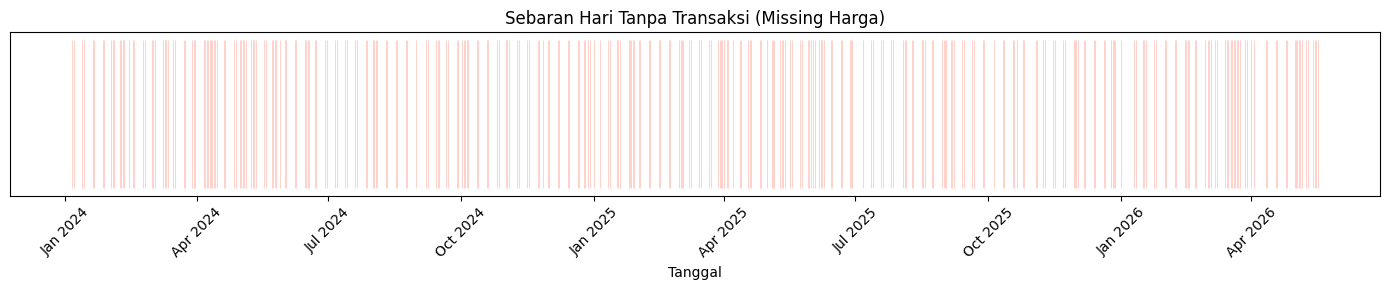

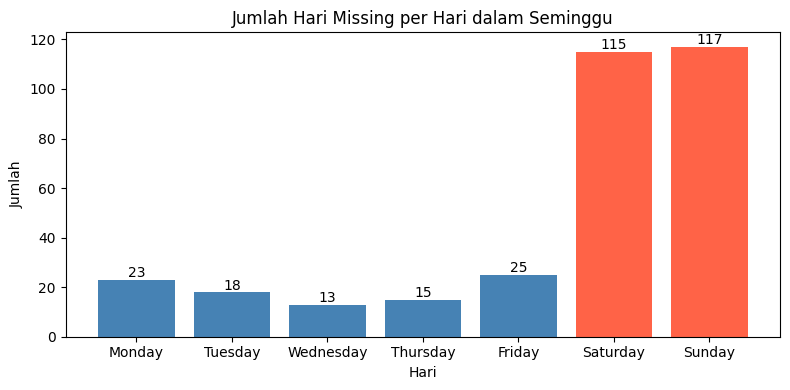

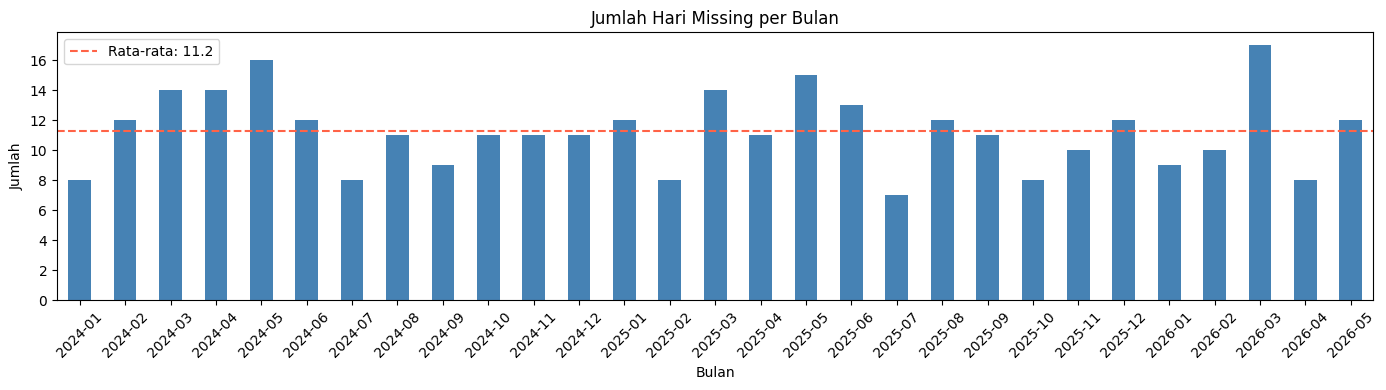

Total missing: 326 hari dari 872 hari (37.4%)

Missing per hari dalam seminggu:
nama_hari
Monday        23
Tuesday       18
Wednesday     13
Thursday      15
Friday        25
Saturday     115
Sunday       117


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('data_gabungan_agri_cuaca.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])

harga_cols = ['Cabe/Lombok Keriting', 'Cabe/Lombok Merah Besar', 'Cabe/Lombok Rawit',
              'Sayuran Bayam', 'Sayuran Kacang Panjang', 'Sayuran Kangkung', 'Sayuran Sawi']

# Missing value marking
df['is_missing'] = df[harga_cols[0]].isna()

# Distribution of missing value
fig, ax = plt.subplots(figsize=(14, 3))
missing_dates = df[df['is_missing']]['tanggal']
ax.vlines(missing_dates, 0, 1, color='tomato', alpha=0.4, linewidth=0.5)
ax.set_title('Distribution of Days Without Price Data')
ax.set_xlabel('Tanggal')
ax.set_yticks([])
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missing_pattern_timeline.png', dpi=150)
plt.show()

# Missing per days
df['nama_hari'] = df['tanggal'].dt.day_name()
hari_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
missing_per_hari = df[df['is_missing']]['nama_hari'].value_counts().reindex(hari_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(missing_per_hari.index, missing_per_hari.values,
              color=['steelblue']*5 + ['tomato', 'tomato'])
ax.set_title('Jumlah Hari Missing per Hari dalam Seminggu')
ax.set_xlabel('Hari')
ax.set_ylabel('Jumlah')
for bar, val in zip(bars, missing_per_hari.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('missing_per_hari.png', dpi=150)
plt.show()

# Missing per month
df['bulan'] = df['tanggal'].dt.to_period('M')
missing_per_bulan = df[df['is_missing']].groupby('bulan').size()

fig, ax = plt.subplots(figsize=(14, 4))
missing_per_bulan.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Jumlah Hari Missing per Bulan')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah')
ax.axhline(y=missing_per_bulan.mean(), color='tomato', linestyle='--', label=f'Rata-rata: {missing_per_bulan.mean():.1f}')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missing_per_bulan.png', dpi=150)
plt.show()

print(f"Total missing: {df['is_missing'].sum()} hari dari {len(df)} hari ({df['is_missing'].mean()*100:.1f}%)")
print(f"\nMissing per hari dalam seminggu:")
print(missing_per_hari.to_string())

# **PREPROCESSING**

## 1. Imputation

In [ ]:
import pandas as pd
df_merged = pd.read_csv('data_gabungan_agri_cuaca.csv')

# Imputation using forward fill
harga_cols = ['Cabe/Lombok Keriting', 'Cabe/Lombok Merah Besar', 'Cabe/Lombok Rawit',
              'Sayuran Bayam', 'Sayuran Kacang Panjang', 'Sayuran Kangkung', 'Sayuran Sawi']

df_merged[harga_cols] = df_merged[harga_cols].ffill()
df_merged.to_csv('data_gabungan_fix.csv', index=False)

## 2. Heatmap

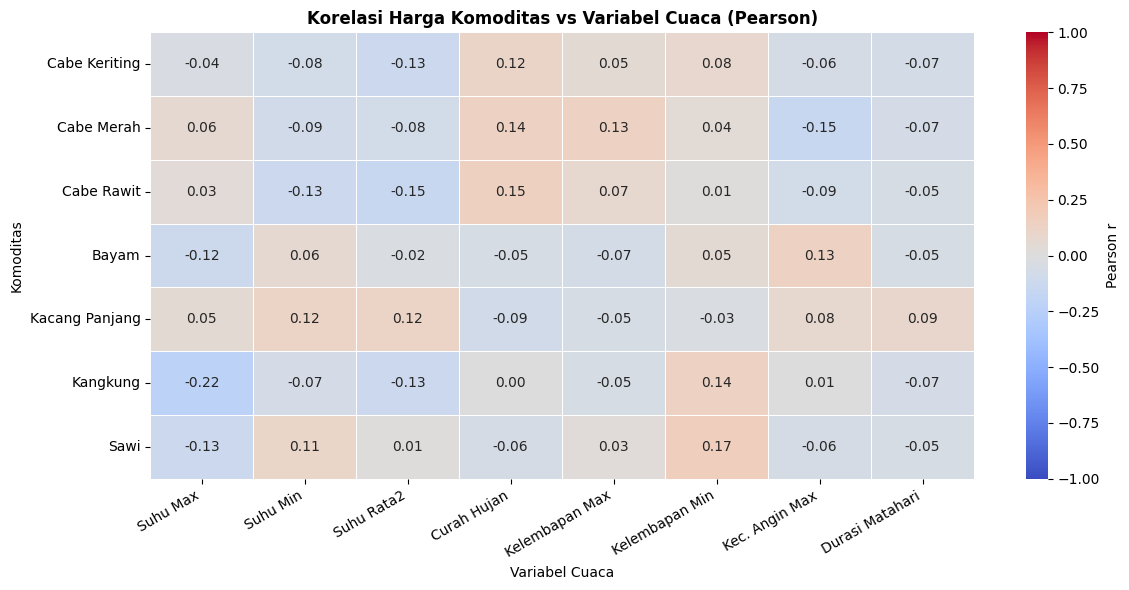

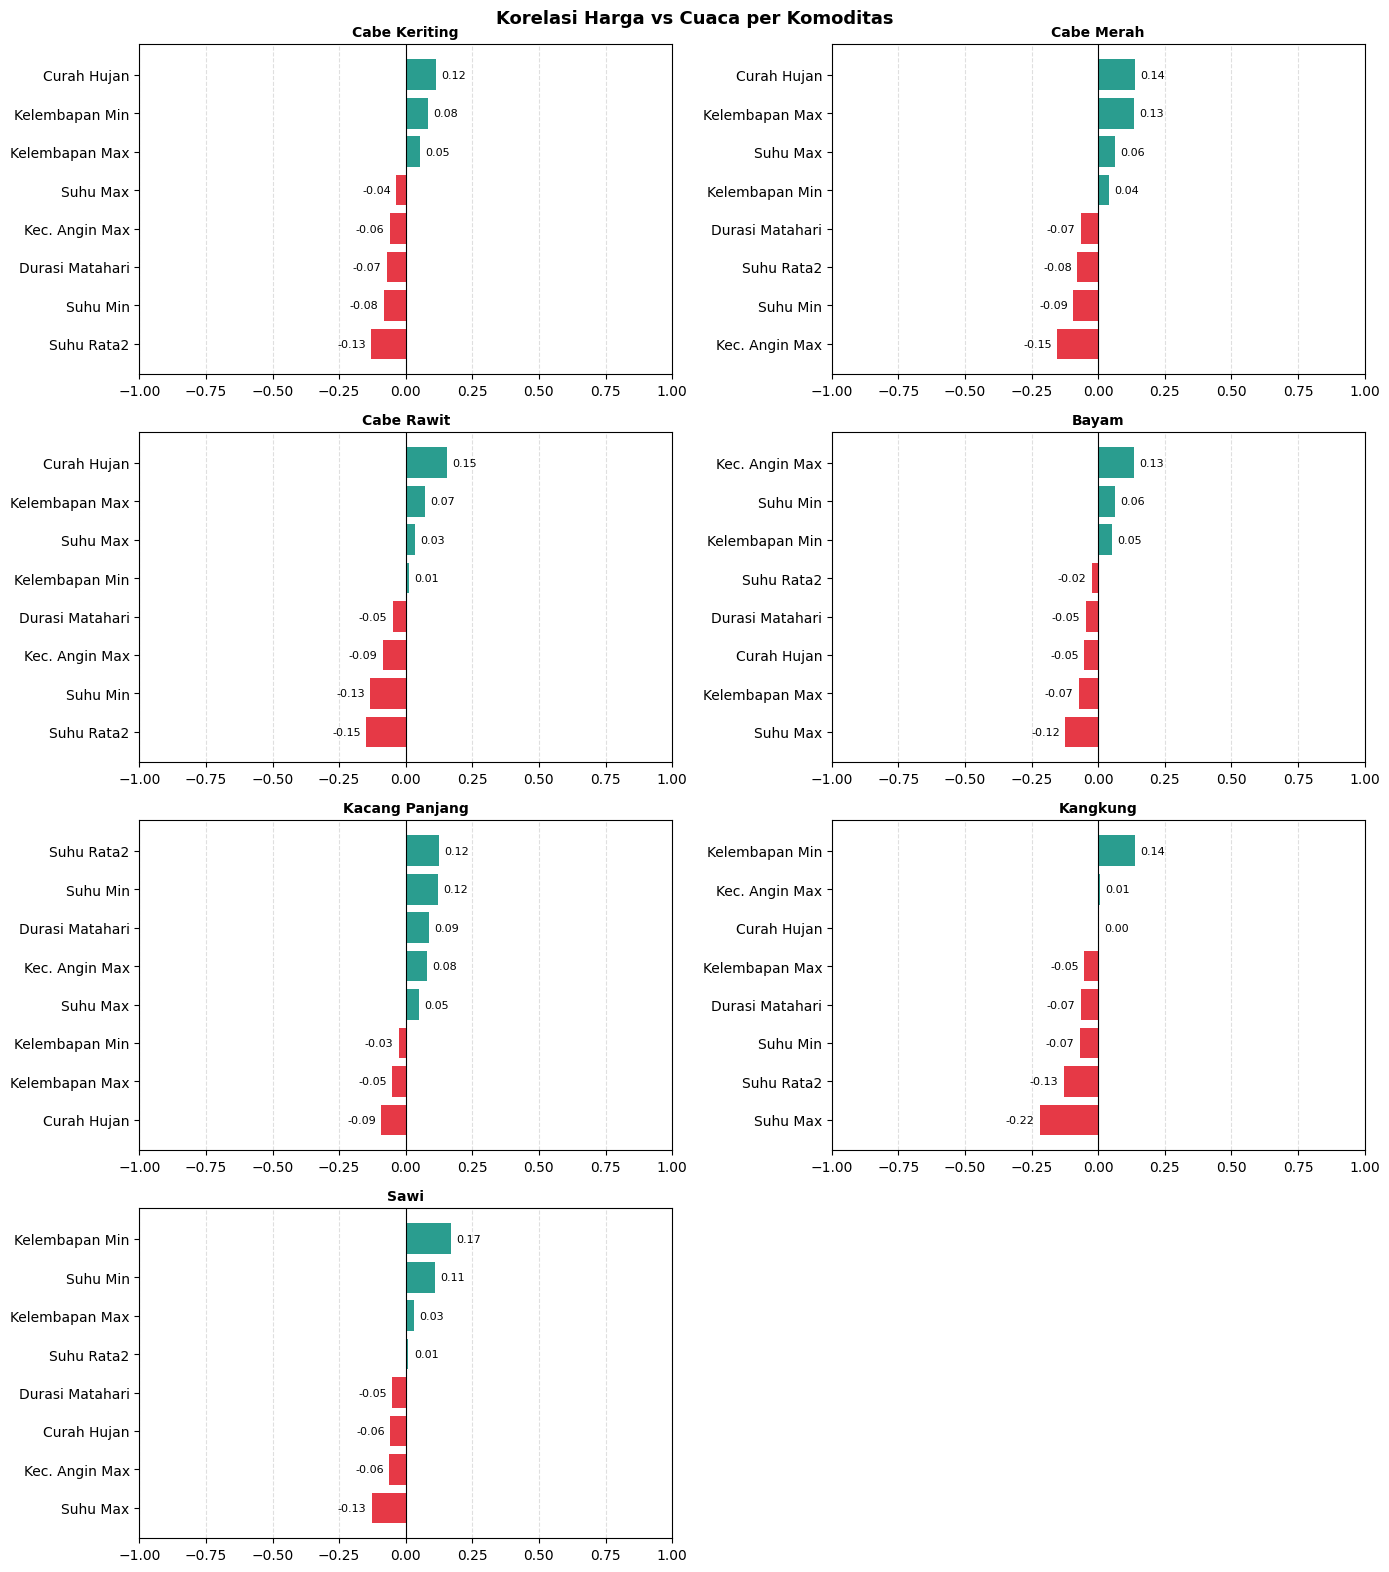

Variabel cuaca paling berkorelasi per komoditas:
  Cabe Keriting        → Suhu Rata2 (r = -0.129)
  Cabe Merah           → Kec. Angin Max (r = -0.154)
  Cabe Rawit           → Curah Hujan (r = 0.155)
  Bayam                → Kec. Angin Max (r = 0.135)
  Kacang Panjang       → Suhu Rata2 (r = 0.124)
  Kangkung             → Suhu Max (r = -0.220)
  Sawi                 → Kelembapan Min (r = 0.170)


In [ ]:
df = pd.read_csv('data_gabungan_fix.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').set_index('tanggal')

harga_cols = ['Cabe/Lombok Keriting', 'Cabe/Lombok Merah Besar', 'Cabe/Lombok Rawit',
              'Sayuran Bayam', 'Sayuran Kacang Panjang', 'Sayuran Kangkung', 'Sayuran Sawi']
cuaca_cols = ['suhu_max_c', 'suhu_min_c', 'suhu_mean_c', 'curah_hujan_mm',
              'kelembapan_max_pct', 'kelembapan_min_pct', 'kecepatan_angin_max_kmh',
              'durasi_sinar_matahari_jam']

df[harga_cols] = df[harga_cols].ffill()

label_harga = {
    'Cabe/Lombok Keriting': 'Cabe Keriting',
    'Cabe/Lombok Merah Besar': 'Cabe Merah',
    'Cabe/Lombok Rawit': 'Cabe Rawit',
    'Sayuran Bayam': 'Bayam',
    'Sayuran Kacang Panjang': 'Kacang Panjang',
    'Sayuran Kangkung': 'Kangkung',
    'Sayuran Sawi': 'Sawi'
}
label_cuaca = {
    'suhu_max_c': 'Suhu Max',
    'suhu_min_c': 'Suhu Min',
    'suhu_mean_c': 'Suhu Rata2',
    'curah_hujan_mm': 'Curah Hujan',
    'kelembapan_max_pct': 'Kelembapan Max',
    'kelembapan_min_pct': 'Kelembapan Min',
    'kecepatan_angin_max_kmh': 'Kec. Angin Max',
    'durasi_sinar_matahari_jam': 'Durasi Matahari'
}

df_harga = df[harga_cols].rename(columns=label_harga)
df_cuaca = df[cuaca_cols].rename(columns=label_cuaca)

# --- Plot 1: Heatmap korelasi harga vs cuaca ---
corr_matrix = pd.concat([df_harga, df_cuaca], axis=1).corr()
corr_harga_cuaca = corr_matrix.loc[list(label_harga.values()), list(label_cuaca.values())]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(corr_harga_cuaca, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title('Korelasi Harga Komoditas vs Variabel Cuaca (Pearson)', fontweight='bold', fontsize=12)
ax.set_xlabel('Variabel Cuaca')
ax.set_ylabel('Komoditas')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('corr_harga_cuaca_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Bar chart korelasi per komoditas (ranked) ---
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for idx, komoditas in enumerate(label_harga.values()):
    row = corr_harga_cuaca.loc[komoditas].sort_values()
    colors = ['#e63946' if v < 0 else '#2a9d8f' for v in row.values]
    axes[idx].barh(row.index, row.values, color=colors)
    axes[idx].axvline(0, color='black', linewidth=0.8)
    axes[idx].set_title(komoditas, fontweight='bold', fontsize=10)
    axes[idx].set_xlim(-1, 1)
    axes[idx].grid(axis='x', linestyle='--', alpha=0.4)
    for i, (val, label) in enumerate(zip(row.values, row.index)):
        axes[idx].text(val + (0.02 if val >= 0 else -0.02), i,
                       f'{val:.2f}', va='center',
                       ha='left' if val >= 0 else 'right', fontsize=8)

# Hapus subplot kosong (ke-8)
fig.delaxes(axes[-1])

fig.suptitle('Korelasi Harga vs Cuaca per Komoditas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('corr_harga_cuaca_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Print variabel cuaca paling berpengaruh per komoditas ---
print("Variabel cuaca paling berkorelasi per komoditas:")
for komoditas in label_harga.values():
    top = corr_harga_cuaca.loc[komoditas].abs().idxmax()
    val = corr_harga_cuaca.loc[komoditas, top]
    print(f"  {komoditas:20s} → {top} (r = {val:.3f})")

In [ ]:
df.describe()

,suhu_max_c,suhu_min_c,suhu_mean_c,curah_hujan_mm,hujan_mm,jam_hujan,kecepatan_angin_max_kmh,kencang_angin_kmh,kelembapan_max_pct,kelembapan_min_pct,durasi_sinar_matahari_detik,kode_cuaca_wmo,durasi_sinar_matahari_jam,Cabe/Lombok Keriting,Cabe/Lombok Merah Besar,Cabe/Lombok Rawit,Sayuran Bayam,Sayuran Kacang Panjang,Sayuran Kangkung,Sayuran Sawi
count,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.00000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000
mean,29.769725,24.529931,26.908257,9.658945,9.658945,10.673165,12.81617,29.802408,96.331697,71.628305,32032.976365,58.846330,8.897959,54128.153670,53409.116972,59145.928899,9503.727064,10821.674312,8216.456422,11592.029817
std,1.229638,0.782595,0.762090,9.932428,9.932428,4.981234,2.79602,5.675579,3.208327,6.155356,10327.478483,8.716969,2.868687,14534.643927,13211.462816,20698.123235,3681.695247,3395.841543,2103.611064,3628.235854
min,25.500000,22.600000,24.200000,0.000000,0.000000,0.000000,7.00000,16.900000,78.780716,47.957360,0.000000,1.000000,0.000000,25000.000000,25000.000000,29000.000000,3000.000000,5000.000000,3000.000000,5000.000000
25%,29.000000,24.000000,26.400000,2.275000,2.275000,7.000000,10.90000,25.900000,95.045775,67.874822,26775.624500,53.000000,7.440000,43000.000000,43000.000000,40000.000000,7000.000000,10000.000000,6375.000000,10000.000000
50%,29.800000,24.500000,26.900000,6.900000,6.900000,10.000000,12.40000,29.200000,97.052060,72.024840,35692.244500,63.000000,9.915000,52000.000000,55000.000000,58000.000000,9000.000000,10000.000000,9000.000000,10000.000000
75%,30.500000,25.000000,27.500000,13.925000,13.925000,14.000000,14.20000,32.800000,98.232955,75.845810,39740.701250,63.000000,11.040000,62500.000000,62000.000000,73000.000000,11000.000000,12000.000000,10000.000000,12000.000000
max,33.200000,27.000000,28.800000,95.700000,95.700000,24.000000,25.00000,57.200000,100.000000,94.500300,43200.000000,65.000000,12.000000,97000.000000,90000.000000,122500.000000,26000.000000,25000.000000,12000.000000,26000.000000


## 2. Parsing Date Features and Feature Selection

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Weather and price dataset.csv')
print(df.dtypes)

date                          object
max_temperature_c            float64
min_temperature_c            float64
mean_temperature_c           float64
rainfall_mm                  float64
precipitation_mm             float64
rain_duration_hours            int64
max_wind_speed_kmh           float64
wind_speed_kmh               float64
max_humidity_pct             float64
min_humidity_pct             float64
sunshine_duration_seconds    float64
wmo_weather_code               int64
sunshine_duration_hours      float64
Curly Chili Pepper             int64
Large Red Chili Pepper         int64
Bird's Eye Chili Pepper        int64
Spinach                        int64
Long Bean                      int64
Water Spinach                  int64
Mustard Greens                 int64
dtype: object


In [2]:
# Parsing Date Feature
df['date'] = pd.to_datetime(df['date'])

df = df.set_index('date')
df = df.sort_index()

print(df.index.dtype)
print(df.head())

df = df.drop(columns=[
    'precipitation_mm',
    'sunshine_duration_seconds',
    'wmo_weather_code',
    'rain_duration_hours',
    'max_wind_speed_kmh',
    'max_temperature_c',
    'min_temperature_c'
])

print(df.shape)
print(df.columns.tolist())

df_raw = df.copy()
print(f"df_raw shape: {df_raw.shape}")
print(f"df_raw columns: {df_raw.columns.tolist()}")

datetime64[ns]
            max_temperature_c  min_temperature_c  mean_temperature_c  \
date                                                                   
2024-01-01               29.8               24.4                26.4   
2024-01-02               28.0               23.3                25.8   
2024-01-03               31.0               24.0                26.5   
2024-01-04               31.2               23.4                27.2   
2024-01-05               27.8               23.8                25.5   

            rainfall_mm  precipitation_mm  rain_duration_hours  \
date                                                             
2024-01-01          7.1               7.1                   12   
2024-01-02         16.1              16.1                   16   
2024-01-03          7.8               7.8                    9   
2024-01-04         13.3              13.3                   13   
2024-01-05         14.8              14.8                   19   

            max_w

## 3. Feature Engineering

In [3]:
N_PRICE = 7
N_WEATHER = 7

price_cols = [
    'Curly Chili Pepper',
    'Large Red Chili Pepper',
    "Bird's Eye Chili Pepper",
    'Spinach',
    'Long Bean',
    'Water Spinach',
    'Mustard Greens'
]

weather_cols = [
    'rainfall_mm',
    'mean_temperature_c',
    'min_humidity_pct',
    'wind_speed_kmh',
    'sunshine_duration_hours'
]

df = df_raw.copy()   # start from the clean dataset

# Create historical features
for col in price_cols:
    for n in range(1, N_PRICE + 1):
        df[f'{col}_lag{n}'] = df[col].shift(n)

for col in weather_cols:
    for n in range(1, N_WEATHER + 1):
        df[f'{col}_lag{n}'] = df[col].shift(n)

# Create one-day-ahead targets
target_cols = price_cols
for col in target_cols:
    df[f'{col}_target_h1'] = df[col].shift(-1)

# Remove rows with missing values caused by shifting
df = df.dropna()

print(f"N_PRICE={N_PRICE}, N_WEATHER={N_WEATHER}")
print(f"Shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")

N_PRICE=7, N_WEATHER=7
Shape: (864, 104)
Number of features: 104


## 4. Dataset Splitting

In [4]:
split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx].reset_index()
test  = df.iloc[split_idx:].reset_index()

target_h1_cols = [f'{c}_target_h1' for c in target_cols]

feature_cols = [
    c for c in train.columns
    if c not in target_cols + target_h1_cols + ['date']
]

print(
    f"Train: {train['date'].min()} to {train['date'].max()} "
    f"({len(train)} days)"
)

print(
    f"Test:  {test['date'].min()} to {test['date'].max()} "
    f"({len(test)} days)"
)

print(f"Number of features: {len(feature_cols)}")

Train: 2024-01-08 00:00:00 to 2025-11-28 00:00:00 (691 days)
Test:  2025-11-29 00:00:00 to 2026-05-20 00:00:00 (173 days)
Number of features: 90


# **MODELLING**

## XGBoost

In [5]:
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import numpy as np
import pandas as pd

xgb_models = {}
xgb_results = []

for target in target_cols:
    target_h1 = f'{target}_target_h1'
    print(f"\nTraining XGBoost: {target} (horizon 1)")

    X_train = train[feature_cols]
    y_train = train[target_h1]

    X_test = test[feature_cols]
    y_test = test[target_h1]

    model = XGBRegressor(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape_val = mean_absolute_percentage_error(y_test, y_pred) * 100

    xgb_models[target] = model

    xgb_results.append({
        'Commodity': target,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape_val
    })

    print(
        f"   MAE: {mae:.2f} | "
        f"RMSE: {rmse:.2f} | "
        f"MAPE: {mape_val:.2f}%"
    )

xgb_results_df = pd.DataFrame(xgb_results)

print("\nAll XGBoost models have been trained successfully!")


Training XGBoost: Curly Chili Pepper (horizon 1)
   MAE: 3273.76 | RMSE: 4679.54 | MAPE: 7.16%

Training XGBoost: Large Red Chili Pepper (horizon 1)
   MAE: 3498.86 | RMSE: 5080.44 | MAPE: 6.96%

Training XGBoost: Bird's Eye Chili Pepper (horizon 1)
   MAE: 6981.62 | RMSE: 9990.88 | MAPE: 9.71%

Training XGBoost: Spinach (horizon 1)
   MAE: 834.22 | RMSE: 1051.10 | MAPE: 7.76%

Training XGBoost: Long Bean (horizon 1)
   MAE: 218.17 | RMSE: 293.65 | MAPE: 2.18%

Training XGBoost: Water Spinach (horizon 1)
   MAE: 956.31 | RMSE: 1173.42 | MAPE: 11.02%

Training XGBoost: Mustard Greens (horizon 1)
   MAE: 383.79 | RMSE: 482.86 | MAPE: 3.84%

All XGBoost models have been trained successfully!


## AutoGluon

In [6]:
!pip install autogluon.tabular

In [7]:
from autogluon.tabular import TabularPredictor

predictors = {}

for target in target_cols:
    target_h1 = f'{target}_target_h1'
    print(f"\nTraining AutoGluon: {target} (horizon 1)")

    # Remove other target columns and original commodity price columns
    cols_to_drop = [c for c in target_h1_cols if c != target_h1] + target_cols
    train_input = train.drop(columns=cols_to_drop)

    # Create a safe folder name
    model_name = (
        target
        .replace("/", "_")
        .replace(" ", "_")
        .replace("'", "")
    )

    predictor = TabularPredictor(
        label=target_h1,
        path=f"models/{model_name}_h1",
        eval_metric="mean_absolute_error",
        problem_type="regression"
    )

    predictor.fit(
        train_input,
        time_limit=300,
        presets="medium_quality"
    )

    predictors[target] = predictor
    print(f"   ✓ Finished: {target}")

print("\nAll AutoGluon models have been trained successfully!")

Verbosity: 2 (Standard Logging)



Training AutoGluon: Curly Chili Pepper (horizon 1)


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       11.35 GB / 12.67 GB (89.6%)
Disk Space Avail:   86.75 GB / 107.72 GB (80.5%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/content/models/Curly_Chili_Pepper_h1"
Train Data Rows:    691
Train Data Columns: 91
Label Column:       Curly Chili Pepper_target_h1
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    11556.02 MB
	Train Data (Original)  Memory Usage: 0.48 MB (0.0% of available memory)
	Inferring 

[1000]	valid_set's l1: 3815.56
[2000]	valid_set's l1: 3815.56
[3000]	valid_set's l1: 3815.56


	-3815.5584	 = Validation score   (-mean_absolute_error)
	39.62s	 = Training   runtime
	0.18s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 299.52s of the 227.50s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/11.0 GB
	Ensemble Weights: {'XGBoost': 0.5, 'LightGBMLarge': 0.333, 'RandomForestMSE': 0.167}
	-3544.5717	 = Validation score   (-mean_absolute_error)
	0.1s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 72.65s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 479.7 rows/s (139 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/content/models/Curly_Chili_Pepper_h1")
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 

...

[1000]	valid_set's l1: 494.729
[2000]	valid_set's l1: 494.692
[3000]	valid_set's l1: 494.692
[4000]	valid_set's l1: 494.692
[5000]	valid_set's l1: 494.692
[6000]	valid_set's l1: 494.692
[7000]	valid_set's l1: 494.692
[8000]	valid_set's l1: 494.692
[9000]	valid_set's l1: 494.692
[10000]	valid_set's l1: 494.692


	-494.6921	 = Validation score   (-mean_absolute_error)
	106.94s	 = Training   runtime
	1.13s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 299.84s of the 166.77s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/11.2 GB
	Ensemble Weights: {'ExtraTreesMSE': 0.68, 'XGBoost': 0.2, 'LightGBMLarge': 0.12}
	-463.8611	 = Validation score   (-mean_absolute_error)
	0.08s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 133.34s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 114.2 rows/s (139 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/content/models/Water_Spinach_h1")
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026

   ✓ Finished: Water Spinach

Training AutoGluon: Mustard Greens (horizon 1)


Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/content/models/Mustard_Greens_h1"
Train Data Rows:    691
Train Data Columns: 91
Label Column:       Mustard Greens_target_h1
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    11509.42 MB
	Train Data (Original)  Memory Usage: 0.48 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting DatetimeFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original data (raw dtype

   ✓ Finished: Mustard Greens

All AutoGluon models have been trained successfully!


# **EVALUATION**

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
from IPython.display import display

target_cols = [
    'Curly Chili Pepper',
    'Large Red Chili Pepper',
    "Bird's Eye Chili Pepper",
    'Spinach',
    'Long Bean',
    'Water Spinach',
    'Mustard Greens'
]

target_h1_cols = [f'{c}_target_h1' for c in target_cols]

def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

autogluon_results = {}

for target in target_cols:
    target_h1 = f'{target}_target_h1'

    # Drop all other target_h1 columns and original price columns
    # Must be identical to cols_to_drop used during training
    cols_to_drop = [c for c in target_h1_cols if c != target_h1] + target_cols
    test_input = test.drop(columns=cols_to_drop)

    # Actual one-day-ahead prices
    actual = test[target_h1].values

    # Prediction
    pred = predictors[target].predict(
        test_input.drop(columns=[target_h1])
    ).values

    autogluon_results[target] = {
        'Best Model': predictors[target].model_best,
        'MAE': round(mean_absolute_error(actual, pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(actual, pred)), 4),
        'MAPE (%)': round(mape(actual, pred), 4)
    }

df_autogluon = pd.DataFrame(autogluon_results).T
df_autogluon.index.name = 'Commodity'

display(
    df_autogluon.style
    .background_gradient(
        subset=['MAE', 'RMSE', 'MAPE (%)'],
        cmap='RdYlGn_r'
    )
    .format({
        'MAE': '{:.4f}',
        'RMSE': '{:.4f}',
        'MAPE (%)': '{:.4f}'
    })
    .set_caption(
        'AutoGluon Results — Best Model per Commodity (Horizon 1)'
    )
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('font-weight', 'bold'),
                ('font-size', '13px'),
                ('margin-bottom', '8px')
            ]
        }
    ])
)

,Best Model,MAE,RMSE,MAPE (%)
Commodity,,,,
Curly Chili Pepper,WeightedEnsemble_L2,3526.9080,4956.1196,7.6209
Large Red Chili Pepper,WeightedEnsemble_L2,3389.4562,4268.5780,6.6493
Bird's Eye Chili Pepper,WeightedEnsemble_L2,6621.8773,9013.7849,9.4758
Spinach,WeightedEnsemble_L2,685.8075,929.5323,6.7422
Long Bean,WeightedEnsemble_L2,159.2023,211.9092,1.5920
Water Spinach,WeightedEnsemble_L2,431.3174,549.0655,5.0528
Mustard Greens,WeightedEnsemble_L2,543.9659,627.6566,5.4397


In [9]:
short_names = {
    'Curly Chili Pepper': 'Curly Chili',
    'Large Red Chili Pepper': 'Large Red Chili',
    "Bird's Eye Chili Pepper": "Bird's Eye Chili",
    'Spinach': 'Spinach',
    'Long Bean': 'Long Bean',
    'Water Spinach': 'Water Spinach',
    'Mustard Greens': 'Mustard Greens'
}

metrics = ['MAE', 'RMSE', 'MAPE (%)']

rows = []
idx = []

for source_name, source_df in [
    ('XGBoost', xgb_results_df.set_index('Commodity')),
    ('AutoGluon', df_autogluon)
]:
    for met in metrics:
        col = met if met in source_df.columns else met.replace(' (%)', '')
        row_vals = [round(source_df.loc[t, col], 2) for t in target_cols]
        avg = round(np.nanmean(row_vals), 2)

        rows.append(row_vals + [avg])
        idx.append((source_name, met))

col_names = [short_names[t] for t in target_cols] + ['Average']

df_recap = pd.DataFrame(
    rows,
    index=pd.MultiIndex.from_tuples(
        idx,
        names=['Model', 'Metric']
    ),
    columns=col_names
)

display(
    df_recap.style
    .background_gradient(
        cmap='RdYlGn_r',
        axis=1,
        subset=pd.IndexSlice[:, col_names]
    )
    .format('{:,.2f}')
    .set_caption(
        'Comparison of MAE, RMSE, and MAPE (%): XGBoost vs AutoGluon'
    )
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('font-weight', 'bold'),
                ('font-size', '13px'),
                ('margin-bottom', '8px')
            ]
        }
    ])
)

## **1. PRICE PREDICTION VS ACTUAL**

### Visualization

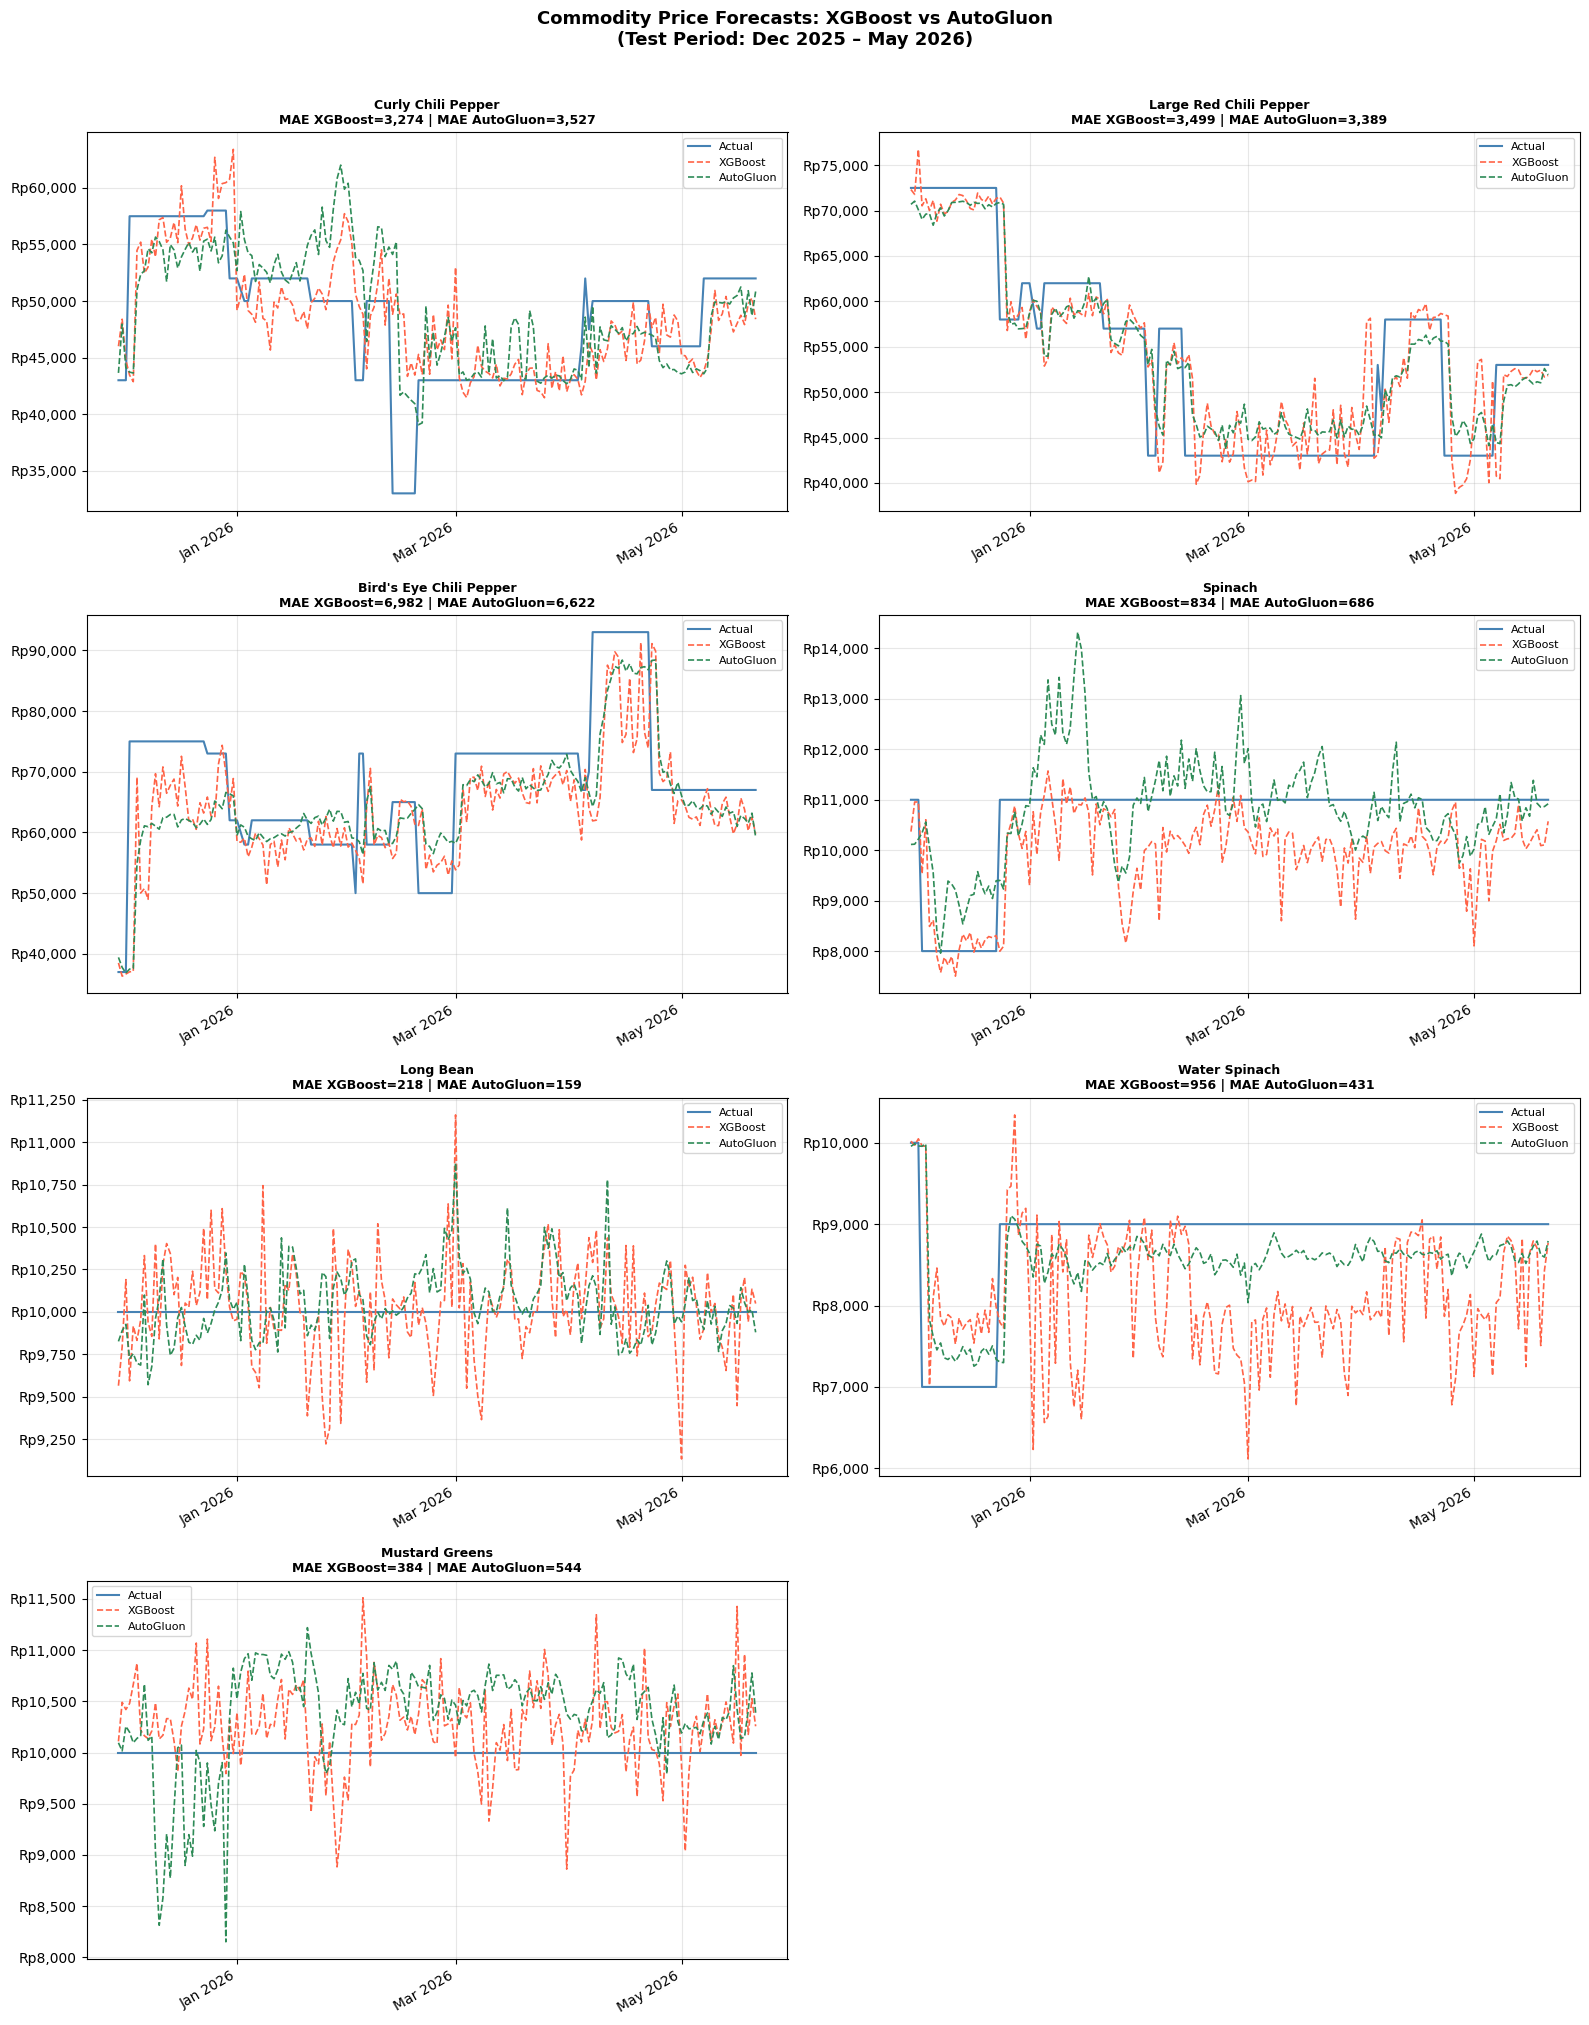

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

dates = pd.to_datetime(test['date']) + pd.Timedelta(days=1)

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, target in enumerate(target_cols):
    target_h1 = f'{target}_target_h1'
    ax = axes[i]

    actual = test[target_h1].values

    # XGBoost prediction
    pred_xgb = xgb_models[target].predict(test[feature_cols])

    # AutoGluon prediction
    cols_to_drop = [c for c in target_h1_cols if c != target_h1] + target_cols
    test_input = test.drop(columns=cols_to_drop)
    pred_ag = predictors[target].predict(
        test_input.drop(columns=[target_h1])
    ).values

    ax.plot(
        dates,
        actual,
        label='Actual',
        color='steelblue',
        linewidth=1.5
    )

    ax.plot(
        dates,
        pred_xgb,
        label='XGBoost',
        color='tomato',
        linewidth=1.2,
        linestyle='--'
    )

    ax.plot(
        dates,
        pred_ag,
        label='AutoGluon',
        color='seagreen',
        linewidth=1.2,
        linestyle='--'
    )

    mae_xgb = xgb_results_df.set_index('Commodity').loc[target, 'MAE']
    mae_ag = df_autogluon.loc[target, 'MAE']

    ax.set_title(
        f"{target}\nMAE XGBoost={mae_xgb:,.0f} | MAE AutoGluon={mae_ag:,.0f}",
        fontsize=9,
        fontweight='bold'
    )

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'Rp{x:,.0f}')
    )

    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle(
    'Commodity Price Forecasts: XGBoost vs AutoGluon\n(Test Period: Dec 2025 – May 2026)',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# **Price Prediction Without Rain Fall**

In [11]:
rain_col = 'rainfall_mm'
rain_lag_cols = [col for col in train.columns if col.startswith(rain_col)]

feature_cols_no_rain = [
    c for c in feature_cols
    if c not in rain_lag_cols
]

print(f"Rainfall columns removed : {rain_lag_cols}")
print(f"Original number of features : {len(feature_cols)}")
print(f"Number of features without rainfall : {len(feature_cols_no_rain)}")

Rainfall columns removed : ['rainfall_mm', 'rainfall_mm_lag1', 'rainfall_mm_lag2', 'rainfall_mm_lag3', 'rainfall_mm_lag4', 'rainfall_mm_lag5', 'rainfall_mm_lag6', 'rainfall_mm_lag7']
Original number of features : 90
Number of features without rainfall : 82


## XGBoost

In [12]:
xgb_models_no_rain = {}
xgb_results_no_rain = []

for target in target_cols:
    target_h1 = f'{target}_target_h1'
    print(f"\nTraining XGBoost (without rainfall): {target}")

    X_train = train[feature_cols_no_rain]
    y_train = train[target_h1]

    X_test = test[feature_cols_no_rain]
    y_test = test[target_h1]

    model = XGBRegressor(random_state=42)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape_val = mean_absolute_percentage_error(y_test, pred) * 100

    xgb_models_no_rain[target] = model

    xgb_results_no_rain.append({
        'Commodity': target,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape_val
    })

    print(
        f"   MAE: {mae:.2f} | "
        f"RMSE: {rmse:.2f} | "
        f"MAPE: {mape_val:.2f}%"
    )

xgb_results_no_rain_df = pd.DataFrame(xgb_results_no_rain)

print("\n=== XGBoost Results Without Rainfall (N_PRICE=7, N_WEATHER=7) ===")
print(xgb_results_no_rain_df.to_string(index=False))


Training XGBoost (without rainfall): Curly Chili Pepper
   MAE: 3065.91 | RMSE: 4480.72 | MAPE: 6.76%

Training XGBoost (without rainfall): Large Red Chili Pepper
   MAE: 3338.42 | RMSE: 4753.01 | MAPE: 6.74%

Training XGBoost (without rainfall): Bird's Eye Chili Pepper
   MAE: 7712.82 | RMSE: 10919.84 | MAPE: 10.64%

Training XGBoost (without rainfall): Spinach
   MAE: 833.56 | RMSE: 1067.20 | MAPE: 7.80%

Training XGBoost (without rainfall): Long Bean
   MAE: 278.75 | RMSE: 383.55 | MAPE: 2.79%

Training XGBoost (without rainfall): Water Spinach
   MAE: 1133.00 | RMSE: 1298.13 | MAPE: 12.98%

Training XGBoost (without rainfall): Mustard Greens
   MAE: 285.34 | RMSE: 405.33 | MAPE: 2.85%

=== XGBoost Results Without Rainfall (N_PRICE=7, N_WEATHER=7) ===
              Commodity         MAE         RMSE  MAPE (%)
     Curly Chili Pepper 3065.910111  4480.720176  6.759483
 Large Red Chili Pepper 3338.415779  4753.007053  6.740134
Bird's Eye Chili Pepper 7712.820042 10919.838193 10.64226

## AutoGluon

In [13]:
predictors_no_rain = {}

for target in target_cols:
    target_h1 = f'{target}_target_h1'
    print(f"\nTraining AutoGluon (without rainfall): {target}")

    # Drop other target columns, original price columns, and rainfall lag features
    cols_to_drop = (
        [c for c in target_h1_cols if c != target_h1]
        + target_cols
        + rain_lag_cols
    )
    cols_to_drop = [c for c in cols_to_drop if c in train.columns]

    train_input = train.drop(columns=cols_to_drop)

    # Create a safe folder name
    model_name = (
        target
        .replace("/", "_")
        .replace(" ", "_")
        .replace("'", "")
    )

    predictor = TabularPredictor(
        label=target_h1,
        path=f"models_no_rain/{model_name}_h1",
        eval_metric="mean_absolute_error",
        problem_type="regression"
    )

    predictor.fit(
        train_input,
        time_limit=300,
        presets="medium_quality"
    )

    predictors_no_rain[target] = predictor
    print(f"   ✓ Finished: {target}")

print("\nAll AutoGluon models (without rainfall) have been trained successfully!")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.90 GB / 12.67 GB (86.0%)
Disk Space Avail:   86.75 GB / 107.72 GB (80.5%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'



Training AutoGluon (without rainfall): Curly Chili Pepper


Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/content/models_no_rain/Curly_Chili_Pepper_h1"
Train Data Rows:    691
Train Data Columns: 83
Label Column:       Curly Chili Pepper_target_h1
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    11156.57 MB
	Train Data (Original)  Memory Usage: 0.44 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting DatetimeFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original

[1000]	valid_set's l1: 4062


	-4061.9814	 = Validation score   (-mean_absolute_error)
	10.23s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 299.87s of the 268.16s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/10.9 GB
	Ensemble Weights: {'XGBoost': 0.478, 'RandomForestMSE': 0.304, 'ExtraTreesMSE': 0.217}
	-3519.135	 = Validation score   (-mean_absolute_error)
	0.11s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 31.98s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 647.0 rows/s (139 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/content/models_no_rain/Curly_Chili_Pepper_h1")
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30

...

[1000]	valid_set's l1: 507.133
[2000]	valid_set's l1: 507.108
[3000]	valid_set's l1: 507.108
[4000]	valid_set's l1: 507.108
[5000]	valid_set's l1: 507.108
[6000]	valid_set's l1: 507.108
[7000]	valid_set's l1: 507.108
[8000]	valid_set's l1: 507.108
[9000]	valid_set's l1: 507.108
[10000]	valid_set's l1: 507.108


	-507.1081	 = Validation score   (-mean_absolute_error)
	100.79s	 = Training   runtime
	0.93s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 299.86s of the 124.23s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/10.9 GB
	Ensemble Weights: {'NeuralNetTorch': 0.96, 'RandomForestMSE': 0.04}
	-396.1423	 = Validation score   (-mean_absolute_error)
	0.1s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 175.9s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 1026.5 rows/s (139 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/content/models_no_rain/Water_Spinach_h1")
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU C

   ✓ Finished: Water Spinach

Training AutoGluon (without rainfall): Mustard Greens


Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/content/models_no_rain/Mustard_Greens_h1"
Train Data Rows:    691
Train Data Columns: 83
Label Column:       Mustard Greens_target_h1
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    11163.95 MB
	Train Data (Original)  Memory Usage: 0.44 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting DatetimeFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original data (r

   ✓ Finished: Mustard Greens

All AutoGluon models (without rainfall) have been trained successfully!


# **Evaluation**

In [14]:
autogluon_results_no_rain = {}

for target in target_cols:
    target_h1 = f'{target}_target_h1'

    cols_to_drop = (
        [c for c in target_h1_cols if c != target_h1]
        + target_cols
        + rain_lag_cols
    )
    cols_to_drop = [c for c in cols_to_drop if c in test.columns]
    test_input = test.drop(columns=cols_to_drop)
    actual = test[target_h1].values

    pred = predictors_no_rain[target].predict(
        test_input.drop(columns=[target_h1])
    ).values

    autogluon_results_no_rain[target] = {
        'Best Model': predictors_no_rain[target].model_best,
        'MAE':        round(mean_absolute_error(actual, pred), 4),
        'RMSE':       round(np.sqrt(mean_squared_error(actual, pred)), 4),
        'MAPE (%)':   round(mape(actual, pred), 4)
    }

df_autogluon_no_rain = pd.DataFrame(autogluon_results_no_rain).T
df_autogluon_no_rain.index.name = 'Commodity'

display(
    df_autogluon_no_rain.style
    .background_gradient(subset=['MAE', 'RMSE', 'MAPE (%)'], cmap='RdYlGn_r')
    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'MAPE (%)': '{:.4f}'})
    .set_caption('AutoGluon Results Without Rainfall — Best Model per Commodity (Horizon 1)')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-weight', 'bold'),
                  ('font-size', '13px'),
                  ('margin-bottom', '8px')]
    }])
)

,Best Model,MAE,RMSE,MAPE (%)
Commodity,,,,
Curly Chili Pepper,WeightedEnsemble_L2,2859.9167,4248.0000,6.3247
Large Red Chili Pepper,WeightedEnsemble_L2,3665.1962,4921.3395,6.7282
Bird's Eye Chili Pepper,WeightedEnsemble_L2,8153.4816,11641.4430,11.8207
Spinach,WeightedEnsemble_L2,583.3792,762.1810,5.5854
Long Bean,WeightedEnsemble_L2,185.4047,252.7606,1.8540
Water Spinach,WeightedEnsemble_L2,1142.5141,1367.7027,13.8025
Mustard Greens,WeightedEnsemble_L2,345.7608,432.4999,3.4576


In [15]:
rows, idx = [], []

for source_name, source_df in [('XGBoost', xgb_results_no_rain_df.set_index('Commodity')),
                               ('AutoGluon', df_autogluon_no_rain)]:
    for met in metrics:
        col = met if met in source_df.columns else met.replace(' (%)', '')
        row_vals = [round(source_df.loc[t, col], 2) for t in target_cols]
        rows.append(row_vals + [round(np.nanmean(row_vals), 2)])
        idx.append((source_name, met))

df_recap_no_rain = pd.DataFrame(
    rows,
    index=pd.MultiIndex.from_tuples(idx, names=['Model', 'Metric']),
    columns=col_names
)

display(
    df_recap_no_rain.style
    .background_gradient(cmap='RdYlGn_r', axis=1)
    .format('{:,.2f}')
    .set_caption(
        'Comparison of MAE, RMSE, and MAPE (%): XGBoost vs AutoGluon (Without Rainfall)'
    )
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-weight', 'bold'),
                  ('font-size', '13px'),
                  ('margin-bottom', '8px')]
    }])
)

### Comparison of prediction models with and without rainfall data

In [16]:
rows, idx = [], []

sources = [
    ('XGBoost - Full Weather',      xgb_results_df.set_index('Commodity')),
    ('XGBoost - Without Rainfall',  xgb_results_no_rain_df.set_index('Commodity')),
    ('AutoGluon - Full Weather',    df_autogluon),
    ('AutoGluon - Without Rainfall', df_autogluon_no_rain),
]

for source_name, source_df in sources:
    for met in metrics:
        col = met if met in source_df.columns else met.replace(' (%)', '')
        row_vals = [round(source_df.loc[t, col], 2) for t in target_cols]
        rows.append(row_vals + [round(np.nanmean(row_vals), 2)])
        idx.append((source_name, met))

df_recap_all = pd.DataFrame(
    rows,
    index=pd.MultiIndex.from_tuples(
        idx,
        names=['Model', 'Metric']
    ),
    columns=col_names
)

display(
    df_recap_all.style
    .background_gradient(cmap='RdYlGn_r', axis=1)
    .format('{:,.2f}')
    .set_caption(
        'Model Comparison: Full Weather Variables vs Without Rainfall'
    )
    .set_table_styles([{
        'selector': 'caption',
        'props': [
            ('font-weight', 'bold'),
            ('font-size', '13px'),
            ('margin-bottom', '8px')
        ]
    }])
)